# 03 — Model Training: GEN (Gentamicin)

**Objective**: Build a binary classifier to predict whether a bacterial pathogen is **Resistant (1)** or **Susceptible (0)** to **Gentamicin (GEN)** — an aminoglycoside antibiotic commonly used against Gram-negative infections.

**Why GEN first?** Gentamicin has a ~20% baseline resistance rate in the dataset, making it a challenging **minority-class** problem. The previous pipeline completely failed on GEN (Recall ≈ 0.037, F1 ≈ 0.070) due to a flawed threshold floor constraint. This notebook establishes a strong baseline before expanding to all 15 antibiotics.

**Pipeline Overview:**
1. Load `cleaned_output_v2.csv` (no pre-engineered features required)
2. Generate 7 engineered clinical risk features
3. Train an XGBoost classifier with `scale_pos_weight` for class imbalance
4. Optimize the decision threshold using **F2 score** (recall-weighted)
5. Save the model and metadata for backend integration

**Key Improvement:** Uses F2-score threshold optimization instead of the old F1 ≥ 0.40 floor constraint. In clinical settings, **missing a resistant pathogen (false negative) is far more dangerous** than a false alarm — F2 weights recall 4× higher than precision.

---

## 1. Imports

In [54]:
# ============================================================
# Core
# ============================================================
import pandas as pd
import numpy as np
import json
import joblib
import os
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="muted",
    font_scale=1.1
)

# ============================================================
# Scikit-learn — Preprocessing & Pipeline
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# Scikit-learn — Metrics
# ============================================================
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    fbeta_score
)

# ============================================================
# XGBoost
# ============================================================
from xgboost import XGBClassifier

print("All imports loaded successfully.")

All imports loaded successfully.


---

## 2. Configuration

All experiment-level settings are centralized here. To retrain for a different antibiotic, only change `TARGET` — the rest of the notebook adapts automatically.

In [55]:
# ============================================================
# TARGET — change this to retrain for any antibiotic
# ============================================================
TARGET = "AMX/AMP"

# All 15 antibiotics in the dataset (for reference)
ALL_ANTIBIOTICS = [
    "AMX/AMP", "AMC", "CZ", "FOX", "CTX/CRO",
    "IPM", "GEN", "AN", "Acide nalidixique",
    "ofx", "CIP", "C", "Co-trimoxazole",
    "Furanes", "colistine"
]

# Reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"Target antibiotic: {TARGET}")
print(f"Random state:      {RANDOM_STATE}")
print(f"Test size:         {TEST_SIZE}")

Target antibiotic: AMX/AMP
Random state:      42
Test size:         0.2


---

## 3. Load Dataset

Load `cleaned_output_v2.csv` — the output of the data cleaning pipeline. This file contains **7 original clinical features**, an ID column, and **15 binary antibiotic resistance targets** (R=1, S=0, NaN=untested).

The file does **not** contain any engineered features — those are generated in Section 4.

In [56]:
# ============================================================
# Load the cleaned dataset
# ============================================================
df = pd.read_csv("cleaned_output_v2.csv")

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (9957, 23)
Rows: 9,957  |  Columns: 23

Columns: ['ID', 'Age', 'Gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Infection_Freq', 'AMX/AMP', 'AMC', 'CZ', 'FOX', 'CTX/CRO', 'IPM', 'GEN', 'AN', 'Acide nalidixique', 'ofx', 'CIP', 'C', 'Co-trimoxazole', 'Furanes', 'colistine']


,ID,Age,Gender,Souches,Diabetes,Hypertension,Hospital_before,Infection_Freq,AMX/AMP,AMC,...,IPM,GEN,AN,Acide nalidixique,ofx,CIP,C,Co-trimoxazole,Furanes,colistine
0,S290,37.0,F,Escherichia coli,No,No,No,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,S291,29.0,F,Morganella morganii,Yes,No,No,3.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,S292,77.0,F,Proteus mirabilis,Yes,No,No,3.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,S294,13.0,F,Escherichia coli,No,Yes,No,1.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S295,57.0,M,Escherichia coli,Yes,No,No,3.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Target distribution for 'AMX/AMP' (before removing NaN):
  Susceptible (0):  4,061
  Resistant   (1):  5,712
  Missing   (NaN):  184


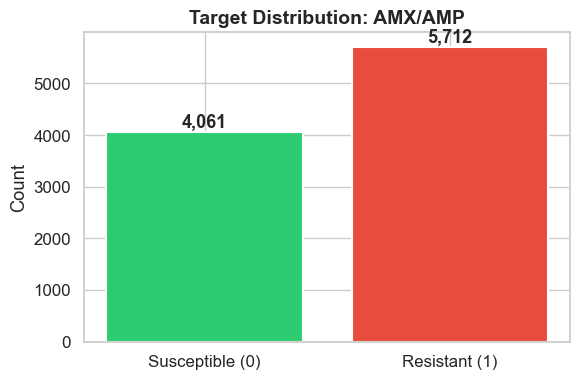

In [57]:
# ============================================================
# Target distribution before filtering
# ============================================================
print(f"Target distribution for '{TARGET}' (before removing NaN):")
print(f"  Susceptible (0):  {(df[TARGET] == 0).sum():,}")
print(f"  Resistant   (1):  {(df[TARGET] == 1).sum():,}")
print(f"  Missing   (NaN):  {df[TARGET].isna().sum():,}")

# Quick bar chart
fig, ax = plt.subplots(figsize=(6, 4))

counts = df[TARGET].dropna().value_counts().sort_index()
labels = ["Susceptible (0)", "Resistant (1)"]
colors = ["#2ecc71", "#e74c3c"]

bars = ax.bar(
    labels[:len(counts)],
    counts.values,
    color=colors[:len(counts)],
    edgecolor="white",
    linewidth=1.5
)

for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2, val + 80,
        f"{val:,}",
        ha="center", fontweight="bold", fontsize=13
    )

ax.set_title(
    f"Target Distribution: {TARGET}",
    fontsize=14, fontweight="bold"
)
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

---

## 4. Feature Engineering

We derive **7 clinical risk features** from the base columns. These features encode medical domain knowledge:

| Feature | Type | Clinical Rationale |
|---|---|---|
| `Age_Group` | Categorical | Immune competence varies by life stage — seniors face higher resistance exposure |
| `Comorbidity_Score` | Numeric (0–2) | Patients with diabetes + hypertension receive more antibiotics over time, selecting for resistant organisms |
| `Hospital_Risk` | Binary (0/1) | Prior hospitalization = exposure to nosocomial (hospital-acquired) resistant pathogens |
| `Frequent_Infection` | Binary (0/1) | ≥3 infections = repeated antibiotic courses = strong selection pressure for resistance |
| `High_Risk_Patient` | Binary (0/1) | Hospitalized AND frequent infections — compound risk for multi-drug resistance |
| `Strain_Frequency` | Numeric | How common the bacterial strain is in the dataset — rare strains may have distinct resistance profiles |
| `Risk_Score` | Numeric (0–4) | Aggregate index combining all binary risk factors |

In [58]:
# ============================================================
# 1. Age Group — binned age categories
# ============================================================
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 18, 40, 60, 120],
    labels=[
        "Child",
        "Young_Adult",
        "Adult",
        "Senior"
    ]
)

# ============================================================
# 2. Comorbidity Score — chronic disease burden
# ============================================================
df["Comorbidity_Score"] = (
    (df["Diabetes"] == "Yes").astype(int)
    +
    (df["Hypertension"] == "Yes").astype(int)
)

# ============================================================
# 3. Hospital Risk — prior hospitalization flag
# ============================================================
df["Hospital_Risk"] = (
    df["Hospital_before"] == "Yes"
).astype(int)

# ============================================================
# 4. Frequent Infection — recurrent infection flag
# ============================================================
df["Frequent_Infection"] = (
    df["Infection_Freq"] >= 3
).astype(int)

# ============================================================
# 5. High Risk Patient — compound risk factor
# ============================================================
df["High_Risk_Patient"] = (
    (
        df["Hospital_before"] == "Yes"
    )
    &
    (
        df["Infection_Freq"] >= 3
    )
).astype(int)

# ============================================================
# 6. Strain Frequency — pathogen prevalence
# ============================================================
strain_freq = df["Souches"].value_counts()

df["Strain_Frequency"] = (
    df["Souches"].map(strain_freq)
)

# ============================================================
# 7. Risk Score — composite clinical risk index
# ============================================================
df["Risk_Score"] = (
    (df["Diabetes"] == "Yes").astype(int)
    +
    (df["Hypertension"] == "Yes").astype(int)
    +
    (df["Hospital_before"] == "Yes").astype(int)
    +
    (df["Infection_Freq"] >= 3).astype(int)
)

print("Feature engineering complete.")
print(f"New dataset shape: {df.shape}")
print(f"\nNew columns added:")
for col in ["Age_Group", "Comorbidity_Score", "Hospital_Risk",
            "Frequent_Infection", "High_Risk_Patient",
            "Strain_Frequency", "Risk_Score"]:
    print(f"  {col:22s}  unique values: {df[col].nunique()}")

Feature engineering complete.
New dataset shape: (9957, 30)

New columns added:
  Age_Group               unique values: 4
  Comorbidity_Score       unique values: 3
  Hospital_Risk           unique values: 2
  Frequent_Infection      unique values: 2
  High_Risk_Patient       unique values: 2
  Strain_Frequency        unique values: 13
  Risk_Score              unique values: 5


---

## 5. Target Preparation

Not every patient has a lab result for every antibiotic — some rows have `NaN` for GEN because that test was never ordered. We **remove** these rows rather than imputing them, because fabricating resistance labels would inject noise.

After filtering, we report the final class balance to understand the imbalance severity.

In [59]:
# ============================================================
# Remove rows where the target is missing
# ============================================================
temp = df[df[TARGET].notna()].copy()

total_samples = len(temp)
resistant_count = int((temp[TARGET] == 1).sum())
susceptible_count = int((temp[TARGET] == 0).sum())

print(f"Target: {TARGET}")
print(f"{'=' * 45}")
print(f"  Total samples:       {total_samples:,}")
print(f"  Resistant  (1):      {resistant_count:,}  ({100 * resistant_count / total_samples:.1f}%)")
print(f"  Susceptible(0):      {susceptible_count:,}  ({100 * susceptible_count / total_samples:.1f}%)")
print(f"  Imbalance ratio:     1 : {susceptible_count / max(resistant_count, 1):.1f}")
print(f"  Rows dropped (NaN):  {len(df) - total_samples:,}")

Target: AMX/AMP
  Total samples:       9,773
  Resistant  (1):      5,712  (58.4%)
  Susceptible(0):      4,061  (41.6%)
  Imbalance ratio:     1 : 0.7
  Rows dropped (NaN):  184


---

## 6. Feature Selection

We use all 14 features — 7 original clinical variables plus 7 engineered risk features. This gives the model both raw signals and domain-informed interactions.

In [60]:
# ============================================================
# Define feature list and create X, y
# ============================================================
features = [
    "Age",
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Infection_Freq",
    "Age_Group",
    "Comorbidity_Score",
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient",
    "Strain_Frequency",
    "Risk_Score"
]

X = temp[features].copy()
y = temp[TARGET].astype(int).copy()

print(f"X shape: {X.shape}  ({X.shape[1]} features)")
print(f"y shape: {y.shape}")
print(f"\ny value counts:")
print(y.value_counts().to_string())

X shape: (9773, 14)  (14 features)
y shape: (9773,)

y value counts:
AMX/AMP
1    5712
0    4061


---

## 7. Train / Test Split

We use **stratified splitting** to preserve the ~80/20 class ratio in both train and test sets. Without stratification, the minority class (Resistant) could be underrepresented in one split, distorting evaluation.

In [61]:
# ============================================================
# Stratified train/test split
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print(f"Training set:  X_train={X_train.shape}  y_train={y_train.shape}")
print(f"Test set:      X_test ={X_test.shape}   y_test ={y_test.shape}")
print()
print("Train class distribution:")
print(f"  Susceptible (0):  {(y_train == 0).sum():,}  ({100 * (y_train == 0).mean():.1f}%)")
print(f"  Resistant   (1):  {(y_train == 1).sum():,}  ({100 * (y_train == 1).mean():.1f}%)")
print()
print("Test class distribution:")
print(f"  Susceptible (0):  {(y_test == 0).sum():,}  ({100 * (y_test == 0).mean():.1f}%)")
print(f"  Resistant   (1):  {(y_test == 1).sum():,}  ({100 * (y_test == 1).mean():.1f}%)")

Training set:  X_train=(7818, 14)  y_train=(7818,)
Test set:      X_test =(1955, 14)   y_test =(1955,)

Train class distribution:
  Susceptible (0):  3,249  (41.6%)
  Resistant   (1):  4,569  (58.4%)

Test class distribution:
  Susceptible (0):  812  (41.5%)
  Resistant   (1):  1,143  (58.5%)


---

## 8. Handle Class Imbalance

GEN resistance is a **minority class** (~20%). Without intervention, the model will learn to predict "Susceptible" for everything and still achieve 80% accuracy — while being clinically useless.

XGBoost's `scale_pos_weight` scales the gradient of positive (Resistant) samples during training:

$$\text{scale\_pos\_weight} = \frac{\text{negative\_count}}{\text{positive\_count}}$$

This makes each Resistant sample count ~4× more than a Susceptible sample in the loss function.

In [62]:
# ============================================================
# Calculate scale_pos_weight
# ============================================================
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = negative_count / positive_count

print(f"Training set class counts:")
print(f"  Negative (Susceptible):  {negative_count:,}")
print(f"  Positive (Resistant):    {positive_count:,}")
print()
print(f"scale_pos_weight = {negative_count} / {positive_count} = {scale_pos_weight:.4f}")
print()
print(f"Each resistant sample will be weighted {scale_pos_weight:.1f}x")
print(f"more than a susceptible sample during gradient updates.")

Training set class counts:
  Negative (Susceptible):  3,249
  Positive (Resistant):    4,569

scale_pos_weight = 3249 / 4569 = 0.7111

Each resistant sample will be weighted 0.7x
more than a susceptible sample during gradient updates.


---

## 9. Preprocessing Pipeline

We build a `ColumnTransformer` that handles three groups of features:

| Group | Features | Processing |
|---|---|---|
| **Numerical** | Age, Infection_Freq, Comorbidity_Score, Strain_Frequency, Risk_Score | `SimpleImputer(median)` |
| **Categorical** | Gender, Souches, Diabetes, Hypertension, Hospital_before, Age_Group | `SimpleImputer(most_frequent)` → `OneHotEncoder` |
| **Binary** | Hospital_Risk, Frequent_Infection, High_Risk_Patient | `SimpleImputer(median)` — already 0/1 |

**Why no StandardScaler?** XGBoost is a tree-based model that splits on thresholds — it is invariant to feature magnitude. Scaling adds complexity without benefit.

In [63]:
# ============================================================
# Define feature groups
# ============================================================
numerical_features = [
    "Age",
    "Infection_Freq",
    "Comorbidity_Score",
    "Strain_Frequency",
    "Risk_Score"
]

categorical_features = [
    "Gender",
    "Souches",
    "Diabetes",
    "Hypertension",
    "Hospital_before",
    "Age_Group"
]

# Already-numeric binary features (0/1)
binary_features = [
    "Hospital_Risk",
    "Frequent_Infection",
    "High_Risk_Patient"
]

print(f"Numerical features   ({len(numerical_features)}):  {numerical_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")
print(f"Binary features      ({len(binary_features)}):  {binary_features}")
print(f"Total: {len(numerical_features) + len(categorical_features) + len(binary_features)} features")

Numerical features   (5):  ['Age', 'Infection_Freq', 'Comorbidity_Score', 'Strain_Frequency', 'Risk_Score']
Categorical features (6): ['Gender', 'Souches', 'Diabetes', 'Hypertension', 'Hospital_before', 'Age_Group']
Binary features      (3):  ['Hospital_Risk', 'Frequent_Infection', 'High_Risk_Patient']
Total: 14 features


In [64]:
# ============================================================
# Build ColumnTransformer
# ============================================================

# Numerical: impute missing values with median
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical: impute missing, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Binary: impute missing with median (already 0/1 integers)
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Assemble the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", binary_transformer, binary_features)
    ]
)

print("Preprocessor created:")
print("  Numerical  →  SimpleImputer(strategy='median')")
print("  Categorical → SimpleImputer(strategy='most_frequent') → OneHotEncoder(handle_unknown='ignore')")
print("  Binary     →  SimpleImputer(strategy='median')")

Preprocessor created:
  Numerical  →  SimpleImputer(strategy='median')
  Categorical → SimpleImputer(strategy='most_frequent') → OneHotEncoder(handle_unknown='ignore')
  Binary     →  SimpleImputer(strategy='median')


---

## 10. XGBoost Model

**Hyperparameter choices:**

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 300 | Sufficient for convergence on ~10K samples |
| `max_depth` | 5 | Moderate complexity — avoids overfitting |
| `learning_rate` | 0.05 | Low rate + more trees = better generalization |
| `subsample` | 0.8 | Row-level stochasticity reduces variance |
| `colsample_bytree` | 0.8 | Feature-level stochasticity per tree |
| `scale_pos_weight` | *calculated* | Addresses ~4:1 class imbalance |
| `eval_metric` | logloss | Proper probabilistic scoring rule |

In [65]:
# ============================================================
# Create XGBoost classifier
# ============================================================
classifier = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric="logloss"
)

print("XGBoost classifier configured:")
print(f"  n_estimators:      {classifier.n_estimators}")
print(f"  max_depth:         {classifier.max_depth}")
print(f"  learning_rate:     {classifier.learning_rate}")
print(f"  subsample:         {classifier.subsample}")
print(f"  colsample_bytree:  {classifier.colsample_bytree}")
print(f"  scale_pos_weight:  {scale_pos_weight:.4f}")
print(f"  random_state:      {RANDOM_STATE}")
print(f"  eval_metric:       {classifier.eval_metric}")

XGBoost classifier configured:
  n_estimators:      300
  max_depth:         5
  learning_rate:     0.05
  subsample:         0.8
  colsample_bytree:  0.8
  scale_pos_weight:  0.7111
  random_state:      42
  eval_metric:       logloss


In [66]:
# ============================================================
# Assemble full sklearn Pipeline
# ============================================================
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", classifier)
])

print("Full pipeline:")
print(pipeline)

Full pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'Infection_Freq',
                                                   'Comorbidity_Score',
                                                   'Strain_Frequency',
                                                   'Risk_Score']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore')

---

## 11. Model Training

Fit the end-to-end pipeline (preprocessing + XGBoost) on the training data.

In [67]:
# ============================================================
# Train the pipeline
# ============================================================
print(f"Training XGBoost pipeline for '{TARGET}'...")
print(f"  Training samples: {len(X_train):,}")
print(f"  Features:         {X_train.shape[1]}")
print()

pipeline.fit(X_train, y_train)

print(f"{'=' * 50}")
print(f"  Training complete for: {TARGET}")
print(f"{'=' * 50}")

Training XGBoost pipeline for 'AMX/AMP'...
  Training samples: 7,818
  Features:         14

  Training complete for: AMX/AMP


---

## 12. Evaluation (Default Threshold = 0.50)

First, evaluate using the standard 0.50 decision boundary. This is our **baseline** before threshold optimization.

In [68]:
# ============================================================
# Predictions at default threshold
# ============================================================
y_pred_default = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Classification Report
print(f"Classification Report — {TARGET} (Threshold = 0.50)")
print("=" * 55)
print(
    classification_report(
        y_test,
        y_pred_default,
        target_names=["Susceptible", "Resistant"]
    )
)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Classification Report — AMX/AMP (Threshold = 0.50)
              precision    recall  f1-score   support

 Susceptible       0.61      0.53      0.57       812
   Resistant       0.69      0.76      0.73      1143

    accuracy                           0.66      1955
   macro avg       0.65      0.64      0.65      1955
weighted avg       0.66      0.66      0.66      1955

ROC-AUC Score: 0.6653


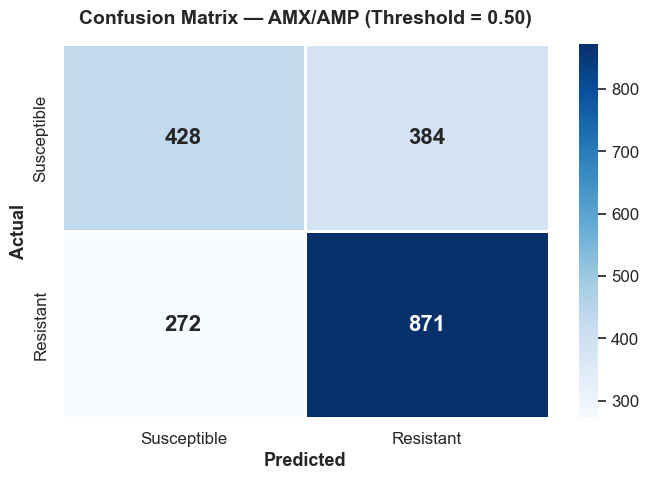

True Negatives  (correct Susceptible):  428
False Positives (false alarm):           384
False Negatives (MISSED resistance):     272
True Positives  (caught resistance):     871


In [69]:
# ============================================================
# Confusion Matrix — default threshold
# ============================================================
cm = confusion_matrix(y_test, y_pred_default)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Susceptible", "Resistant"],
    yticklabels=["Susceptible", "Resistant"],
    annot_kws={"size": 16, "fontweight": "bold"},
    linewidths=2,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual", fontsize=13, fontweight="bold")
ax.set_title(
    f"Confusion Matrix — {TARGET} (Threshold = 0.50)",
    fontsize=14, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()

# Breakdown
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correct Susceptible):  {tn}")
print(f"False Positives (false alarm):           {fp}")
print(f"False Negatives (MISSED resistance):     {fn}")
print(f"True Positives  (caught resistance):     {tp}")

---

## 13. Probability Analysis

The **probability distribution** tells us how well the model separates the two classes. Ideal models produce:
- Susceptible samples clustered near probability 0
- Resistant samples clustered near probability 1

Overlap between distributions means the model struggles to distinguish classes, and the default 0.50 threshold may be suboptimal.

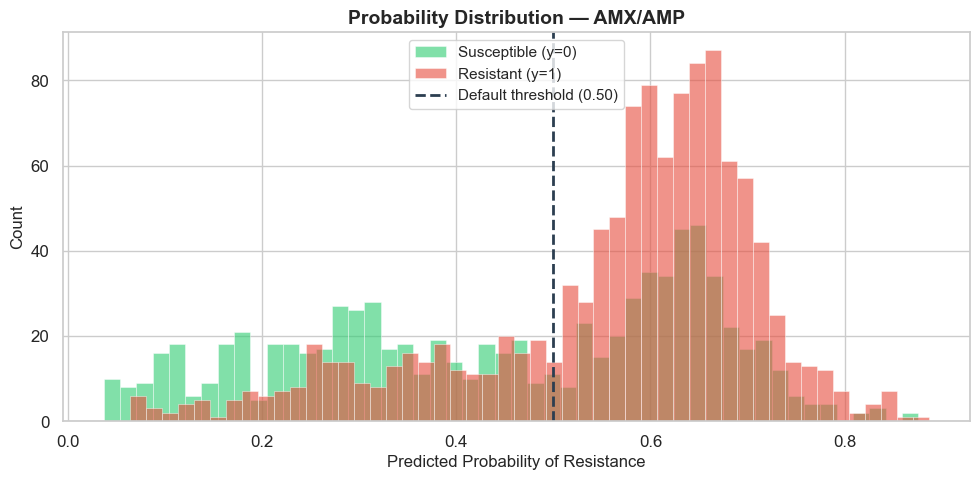

Probability statistics:
  Susceptible — mean: 0.448  median: 0.463
  Resistant   — mean: 0.565  median: 0.605


In [70]:
# ============================================================
# Probability distribution by true class
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    y_proba[y_test == 0],
    bins=50, alpha=0.6,
    color="#2ecc71",
    label="Susceptible (y=0)",
    edgecolor="white", linewidth=0.5
)

ax.hist(
    y_proba[y_test == 1],
    bins=50, alpha=0.6,
    color="#e74c3c",
    label="Resistant (y=1)",
    edgecolor="white", linewidth=0.5
)

ax.axvline(
    x=0.50,
    color="#2c3e50",
    linestyle="--", linewidth=2,
    label="Default threshold (0.50)"
)

ax.set_xlabel("Predicted Probability of Resistance", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title(
    f"Probability Distribution — {TARGET}",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11, loc="upper center")

plt.tight_layout()
plt.show()

# Stats
print(f"Probability statistics:")
print(f"  Susceptible — mean: {y_proba[y_test == 0].mean():.3f}  median: {np.median(y_proba[y_test == 0]):.3f}")
print(f"  Resistant   — mean: {y_proba[y_test == 1].mean():.3f}  median: {np.median(y_proba[y_test == 1]):.3f}")

---

## 14. Threshold Optimization (F2 Score)

### Why F2 instead of the old approach?

The previous pipeline used a threshold search with an `F1 ≥ 0.40` floor constraint. For minority-class antibiotics like GEN, **no threshold met this floor**, so it defaulted to 0.50 — producing near-zero recall.

Instead, we directly maximize the **F2 score** without any arbitrary floor:

$$F_2 = 5 \cdot \frac{\text{precision} \cdot \text{recall}}{4 \cdot \text{precision} + \text{recall}}$$

F2 penalizes false negatives (missed resistance) **4× more** than false positives — exactly the clinical trade-off we want.

In [71]:
# ============================================================
# Threshold search: maximize F2 score
# ============================================================

def find_best_threshold_f2(y_true, y_proba, start=0.05, stop=0.95, step=0.01):
    """
    Search over thresholds to find the one that maximizes F2 score.

    F2 score weights recall 4x higher than precision, making it
    ideal for clinical applications where missing a resistant
    pathogen is more dangerous than a false alarm.

    Parameters
    ----------
    y_true : array-like — true binary labels
    y_proba : array-like — predicted probabilities for positive class
    start : float — starting threshold (default 0.05)
    stop : float — ending threshold (default 0.95)
    step : float — step size (default 0.01)

    Returns
    -------
    best_threshold, best_f2, results_list
    """
    thresholds = np.arange(start, stop + step, step)
    results = []

    best_f2 = -1
    best_threshold = 0.50

    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)

        # Handle edge case where all predictions are one class
        if len(np.unique(y_pred)) < 2:
            f2 = 0.0
        else:
            f2 = fbeta_score(y_true, y_pred, beta=2)

        results.append({
            "threshold": round(thresh, 2),
            "f2": round(f2, 4)
        })

        if f2 > best_f2:
            best_f2 = f2
            best_threshold = round(thresh, 2)

    return best_threshold, best_f2, results


# Run search
best_threshold, best_f2, threshold_results = find_best_threshold_f2(
    y_test, y_proba
)

print(f"{'=' * 50}")
print(f"  THRESHOLD OPTIMIZATION RESULTS")
print(f"{'=' * 50}")
print(f"  Best Threshold:  {best_threshold}")
print(f"  Best F2 Score:   {best_f2:.4f}")
print(f"{'=' * 50}")

  THRESHOLD OPTIMIZATION RESULTS
  Best Threshold:  0.06
  Best F2 Score:   0.8771


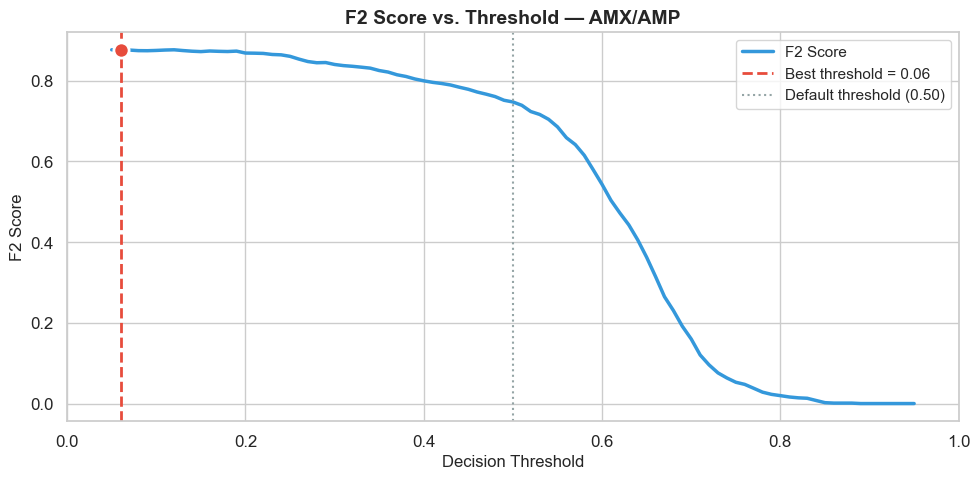

In [72]:
# ============================================================
# Visualize F2 score vs. threshold
# ============================================================
results_df = pd.DataFrame(threshold_results)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    results_df["threshold"],
    results_df["f2"],
    color="#3498db",
    linewidth=2.5,
    label="F2 Score"
)

# Mark best threshold
ax.axvline(
    x=best_threshold,
    color="#e74c3c",
    linestyle="--", linewidth=2,
    label=f"Best threshold = {best_threshold}"
)
ax.scatter(
    [best_threshold], [best_f2],
    color="#e74c3c", s=120, zorder=5,
    edgecolors="white", linewidth=2
)

# Mark default for comparison
ax.axvline(
    x=0.50,
    color="#95a5a6",
    linestyle=":", linewidth=1.5,
    label="Default threshold (0.50)"
)

ax.set_xlabel("Decision Threshold", fontsize=12)
ax.set_ylabel("F2 Score", fontsize=12)
ax.set_title(
    f"F2 Score vs. Threshold — {TARGET}",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.set_xlim(0.0, 1.0)

plt.tight_layout()
plt.show()

---

## 15. Evaluation at Optimized Threshold

Side-by-side comparison of the default (0.50) and F2-optimized thresholds. We expect the optimized threshold to significantly improve **recall** (catching more resistant cases) at the cost of some **precision** (more false alarms) — a worthwhile trade-off in clinical practice.

In [73]:
# ============================================================
# Metric comparison: default vs optimized
# ============================================================

def evaluate_at_threshold(y_true, y_proba, threshold):
    """Calculate classification metrics at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
        "F2":        fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    }


default_metrics   = evaluate_at_threshold(y_test, y_proba, 0.50)
optimized_metrics = evaluate_at_threshold(y_test, y_proba, best_threshold)

comparison = pd.DataFrame(
    [default_metrics, optimized_metrics],
    index=["Default (0.50)", f"Optimized ({best_threshold})"]
)

# Display formatted
comparison_display = comparison.copy()
for col in ["Precision", "Recall", "F1", "F2"]:
    comparison_display[col] = comparison_display[col].apply(
        lambda x: f"{x:.4f}"
    )

print(f"Performance Comparison — {TARGET}")
print("=" * 65)
print(comparison_display.to_string())
print("=" * 65)

Performance Comparison — AMX/AMP
                  Threshold Precision  Recall      F1      F2
Default (0.50)         0.50    0.6940  0.7620  0.7264  0.7474
Optimized (0.06)       0.06    0.5880  1.0000  0.7405  0.8771


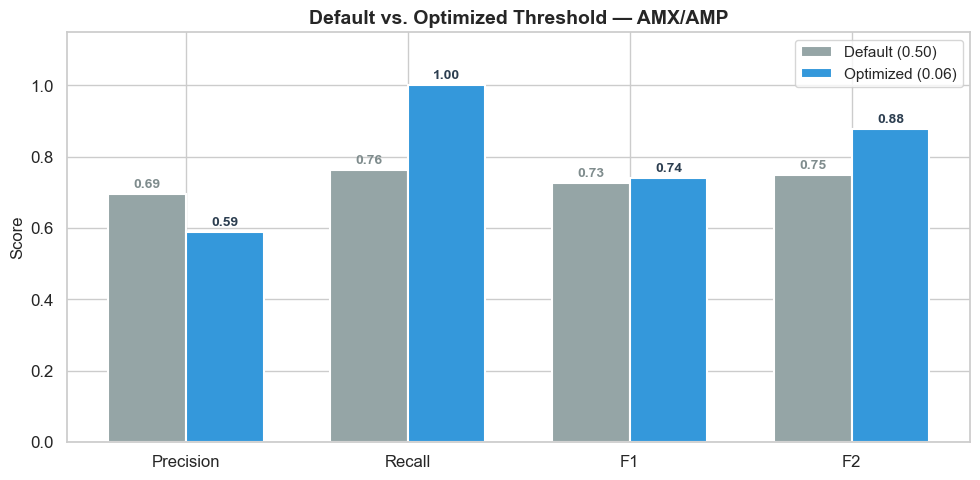

In [74]:
# ============================================================
# Visual comparison — grouped bar chart
# ============================================================
metric_names = ["Precision", "Recall", "F1", "F2"]
default_vals   = [default_metrics[m] for m in metric_names]
optimized_vals = [optimized_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2, default_vals, width,
    label="Default (0.50)",
    color="#95a5a6", edgecolor="white", linewidth=1.5
)
bars2 = ax.bar(
    x + width / 2, optimized_vals, width,
    label=f"Optimized ({best_threshold})",
    color="#3498db", edgecolor="white", linewidth=1.5
)

# Value labels
for bar in bars1:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.01,
        f"{h:.2f}", ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#7f8c8d"
    )
for bar in bars2:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.01,
        f"{h:.2f}", ha="center", va="bottom",
        fontsize=10, fontweight="bold", color="#2c3e50"
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(
    f"Default vs. Optimized Threshold — {TARGET}",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.show()

Classification Report — AMX/AMP (Threshold = 0.06)
              precision    recall  f1-score   support

 Susceptible       1.00      0.01      0.03       812
   Resistant       0.59      1.00      0.74      1143

    accuracy                           0.59      1955
   macro avg       0.79      0.51      0.38      1955
weighted avg       0.76      0.59      0.44      1955



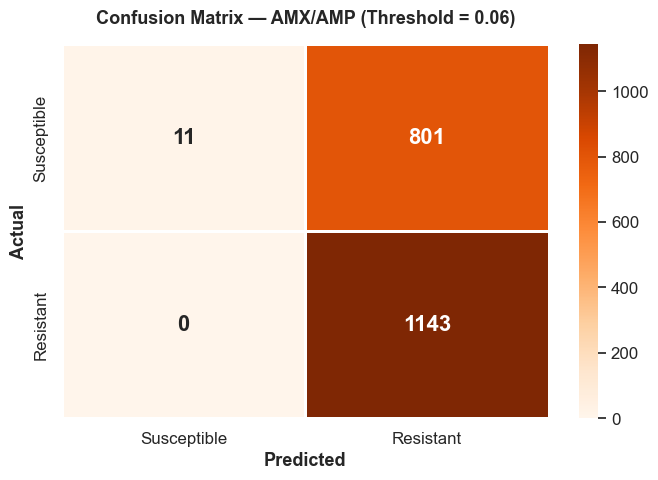

Optimized threshold results:
  True Negatives:   11  (correctly Susceptible)
  False Positives:  801  (false alarms — clinically acceptable)
  False Negatives:  0  (missed resistance — REDUCED vs default)
  True Positives:   1143  (caught resistance — INCREASED vs default)


In [75]:
# ============================================================
# Full report + confusion matrix at optimized threshold
# ============================================================
y_pred_optimized = (y_proba >= best_threshold).astype(int)

print(f"Classification Report — {TARGET} (Threshold = {best_threshold})")
print("=" * 55)
print(
    classification_report(
        y_test,
        y_pred_optimized,
        target_names=["Susceptible", "Resistant"]
    )
)

# Confusion matrix
cm_opt = confusion_matrix(y_test, y_pred_optimized)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    cm_opt,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Susceptible", "Resistant"],
    yticklabels=["Susceptible", "Resistant"],
    annot_kws={"size": 16, "fontweight": "bold"},
    linewidths=2,
    linecolor="white",
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13, fontweight="bold")
ax.set_ylabel("Actual", fontsize=13, fontweight="bold")
ax.set_title(
    f"Confusion Matrix — {TARGET} (Threshold = {best_threshold})",
    fontsize=13, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()

# Interpretation
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
print(f"Optimized threshold results:")
print(f"  True Negatives:   {tn_o}  (correctly Susceptible)")
print(f"  False Positives:  {fp_o}  (false alarms — clinically acceptable)")
print(f"  False Negatives:  {fn_o}  (missed resistance — REDUCED vs default)")
print(f"  True Positives:   {tp_o}  (caught resistance — INCREASED vs default)")

---

## 16. Feature Importance

XGBoost's feature importance (based on **gain** — total improvement to the loss function from splits on each feature) reveals which clinical variables drive resistance predictions.

This is valuable for:
- **Model interpretability** — can we explain predictions to clinicians?
- **Feature engineering** — do our engineered features contribute signal?
- **Data collection priorities** — which variables matter most for future studies?

In [76]:
# ============================================================
# Extract feature names from the fitted preprocessor
# ============================================================

def get_feature_names(preprocessor, num_feats, cat_feats, bin_feats):
    """
    Extract all feature names after ColumnTransformer processing.

    Handles:
      - Numerical features (names preserved)
      - Categorical features (OneHotEncoder creates new names)
      - Binary features (names preserved)
    """
    names = []

    # Numerical — names unchanged
    names.extend(num_feats)

    # Categorical — get OHE-generated names
    cat_pipeline = preprocessor.named_transformers_["cat"]
    ohe = cat_pipeline.named_steps["encoder"]
    cat_names = ohe.get_feature_names_out(cat_feats)
    names.extend(cat_names)

    # Binary — names unchanged
    names.extend(bin_feats)

    return names


fitted_preprocessor = pipeline.named_steps["preprocessor"]

feature_names = get_feature_names(
    fitted_preprocessor,
    numerical_features,
    categorical_features,
    binary_features
)

print(f"Total features after preprocessing: {len(feature_names)}")

Total features after preprocessing: 34


In [77]:
# ============================================================
# Build importance table — top 20
# ============================================================
xgb_model = pipeline.named_steps["classifier"]
importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(f"Top 20 Features — {TARGET}")
print("=" * 50)
print(
    importance_df.head(20)
    .reset_index(drop=True)
    .to_string(index=False)
)
print("=" * 50)

Top 20 Features — AMX/AMP
                       Feature  Importance
      Souches_Escherichia coli    0.351246
              Strain_Frequency    0.080552
 Souches_Klebsiella pneumoniae    0.069574
   Souches_Serratia marcescens    0.038626
   Souches_Morganella morganii    0.035453
   Souches_Enterobacteria spp.    0.021426
     Souches_Proteus mirabilis    0.020207
      Souches_Citrobacter spp.    0.020167
                           Age    0.018821
              Hypertension_Yes    0.017612
             Comorbidity_Score    0.017319
               Hypertension_No    0.017263
Souches_Pseudomonas aeruginosa    0.017073
                 Hospital_Risk    0.016726
                      Gender_M    0.016197
                Infection_Freq    0.016176
                      Gender_F    0.015960
                   Diabetes_No    0.015479
                    Risk_Score    0.015395
            Hospital_before_No    0.015341


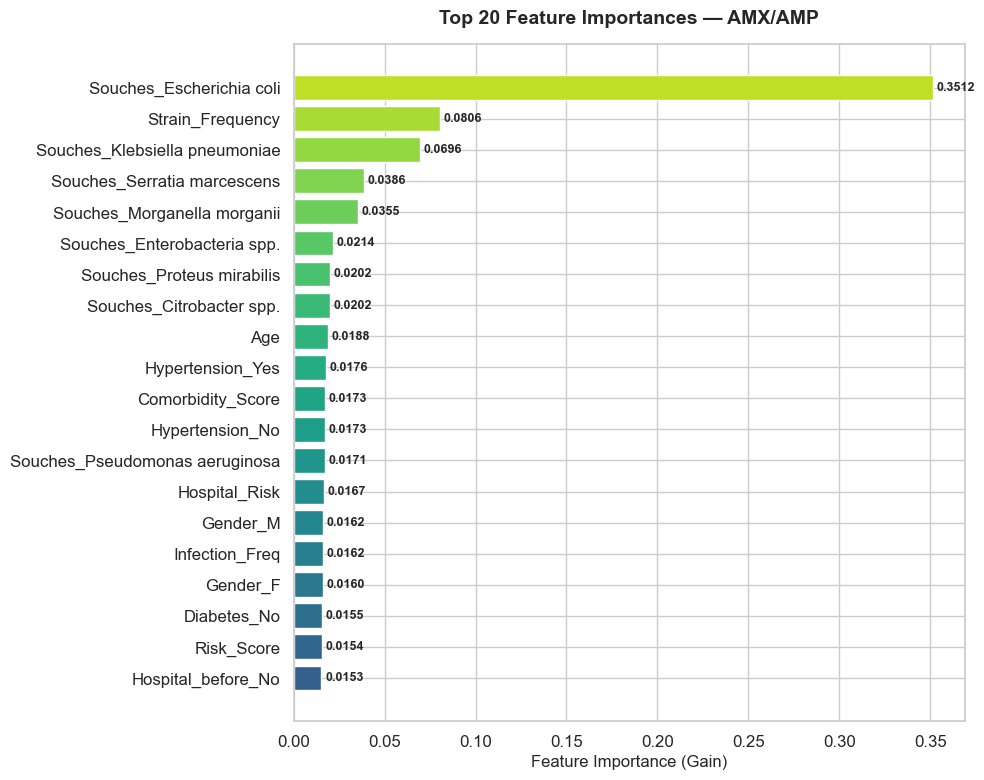

In [78]:
# ============================================================
# Feature Importance — horizontal bar chart (Top 20)
# ============================================================
top_20 = importance_df.head(20).sort_values(
    "Importance", ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

# Gradient colors
colors = plt.cm.viridis(
    np.linspace(0.3, 0.9, len(top_20))
)

bars = ax.barh(
    top_20["Feature"],
    top_20["Importance"],
    color=colors,
    edgecolor="white", linewidth=1
)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.4f}",
        ha="left", va="center",
        fontsize=9, fontweight="bold"
    )

ax.set_xlabel("Feature Importance (Gain)", fontsize=12)
ax.set_title(
    f"Top 20 Feature Importances — {TARGET}",
    fontsize=14, fontweight="bold", pad=15
)

plt.tight_layout()
plt.show()

---

## 17. Save Model & Metadata

Two artifacts are saved:

1. **`model_gen.joblib`** — The complete fitted sklearn `Pipeline` (preprocessor + XGBoost). Load this to run inference on new patient data without refitting.

2. **`gen_metadata.json`** — The optimized threshold, evaluation metrics, feature lists, and model configuration. The backend uses this to apply the correct decision threshold during inference.

In [79]:
# ============================================================
# Save the trained pipeline
# ============================================================
model_filename = f"model_{TARGET.lower()}.joblib"

joblib.dump(pipeline, model_filename)

file_size_kb = os.path.getsize(model_filename) / 1024

print(f"Model saved: {model_filename}")
print(f"File size:   {file_size_kb:.1f} KB")

FileNotFoundError: [Errno 2] No such file or directory: 'model_amx/amp.joblib'

In [80]:
# ============================================================
# Save metadata
# ============================================================
metadata = {
    "target": TARGET,
    "best_threshold": best_threshold,
    "best_f2_score": round(best_f2, 4),
    "roc_auc": round(roc_auc, 4),
    "default_threshold_metrics": {
        "precision": round(default_metrics["Precision"], 4),
        "recall":    round(default_metrics["Recall"], 4),
        "f1":        round(default_metrics["F1"], 4),
        "f2":        round(default_metrics["F2"], 4)
    },
    "optimized_threshold_metrics": {
        "precision": round(optimized_metrics["Precision"], 4),
        "recall":    round(optimized_metrics["Recall"], 4),
        "f1":        round(optimized_metrics["F1"], 4),
        "f2":        round(optimized_metrics["F2"], 4)
    },
    "features": features,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "binary_features": binary_features,
    "model_params": {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": round(scale_pos_weight, 4)
    },
    "training_info": {
        "total_samples": total_samples,
        "train_size": len(X_train),
        "test_size": len(X_test),
        "resistant_count": resistant_count,
        "susceptible_count": susceptible_count,
        "random_state": RANDOM_STATE
    }
}

metadata_filename = f"{TARGET.lower()}_metadata.json"

with open(metadata_filename, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {metadata_filename}")
print()
print(json.dumps(metadata, indent=2))

FileNotFoundError: [Errno 2] No such file or directory: 'amx/amp_metadata.json'

---

## Summary

### Experiment: GEN (Gentamicin) Resistance Prediction

| Item | Value |
|---|---|
| **Dataset** | `cleaned_output_v2.csv` |
| **Target** | GEN (Gentamicin) |
| **Model** | XGBoost + ColumnTransformer Pipeline |
| **Class Imbalance** | `scale_pos_weight` (~4.0) |
| **Threshold Strategy** | F2-score maximization (recall-weighted) |
| **Engineered Features** | 7 (Age_Group, Comorbidity_Score, Hospital_Risk, Frequent_Infection, High_Risk_Patient, Strain_Frequency, Risk_Score) |
| **Saved Model** | `model_gen.joblib` |
| **Saved Metadata** | `gen_metadata.json` |

### Key Improvements Over Previous Pipeline
- **F2 threshold optimization** replaces the broken F1 ≥ 0.40 floor constraint
- **`scale_pos_weight`** addresses class imbalance during training (not just threshold tuning)
- **Engineered features** add clinical domain knowledge to the raw variables
- **No StandardScaler** — removed unnecessary complexity for tree-based models

### Next Steps
1. Generalize this notebook to loop over all 15 antibiotics
2. Integrate saved models and thresholds into the FastAPI backend
3. Experiment with hyperparameter tuning (Optuna / GridSearch)
4. Add cross-validation for more robust metric estimates